In [1]:
# Imports and setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle
import time
import warnings

# suppressing warnings for cleaner output
warnings.filterwarnings('ignore')

# scikit-learn stuffxa
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# plotting configs
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)

# cloning the repo (make sure git is installed)
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject


Cloning into 'PRMLProject'...
remote: Enumerating objects: 280, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 280 (delta 14), reused 11 (delta 5), pack-reused 239 (from 1)
Receiving objects: 100% (280/280), 216.59 MiB | 14.35 MiB/s, done.
Resolving deltas: 100% (107/107), done.
Updating files: 100% (74/74), done.
Filtering content: 100% (16/16), 1.40 GiB | 42.82 MiB/s, done.
/content/PRMLProject


In [2]:
# function to load pickled data
def unpickle(file_path):
    with open(file_path, 'rb') as f:
        return pickle.load(f)

# loading HoG + PCA processed features
X_train = unpickle("PreProcessedData/TrainFeaturesHoG_PCA.pkl")
y_train = unpickle("PreProcessedData/Labels_train.pkl")
X_test = unpickle("PreProcessedData/TestFeaturesHoG_PCA.pkl")
y_test = unpickle("PreProcessedData/Labels_test.pkl")

# flattening feature arrays
X_train = X_train.reshape(len(X_train), -1)
X_test = X_test.reshape(len(X_test), -1)

# making sure labels are in proper shape
y_train = np.array(y_train).reshape(-1)
y_test = np.array(y_test).reshape(-1)

# quick check
print("Data loaded successfully ✅")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Data loaded successfully ✅
Train shape: (50000, 170)
Test shape: (10000, 170)


In [3]:
# trying out different SVM kernels
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
accuracies = []
times = []


In [4]:
# Initialize variables to store models, predictions, accuracies, and times
models = {}
predictions = {}
accuracies = []
times = []


Training and Evaluating Kernels:   0%|          | 0/4 [00:00<?, ?it/s]


Starting with the 'linear' kernel...
Done! Accuracy: 0.5340 | Time taken: 499.62 sec

Classification Report for LINEAR Kernel:
              precision    recall  f1-score   support

           0       0.58      0.62      0.60      1000
           1       0.62      0.64      0.63      1000
           2       0.44      0.42      0.43      1000
           3       0.38      0.32      0.35      1000
           4       0.45      0.50      0.48      1000
           5       0.46      0.41      0.43      1000
           6       0.53      0.63      0.57      1000
           7       0.59      0.57      0.58      1000
           8       0.59      0.59      0.59      1000
           9       0.67      0.64      0.66      1000

    accuracy                           0.53     10000
   macro avg       0.53      0.53      0.53     10000
weighted avg       0.53      0.53      0.53     10000



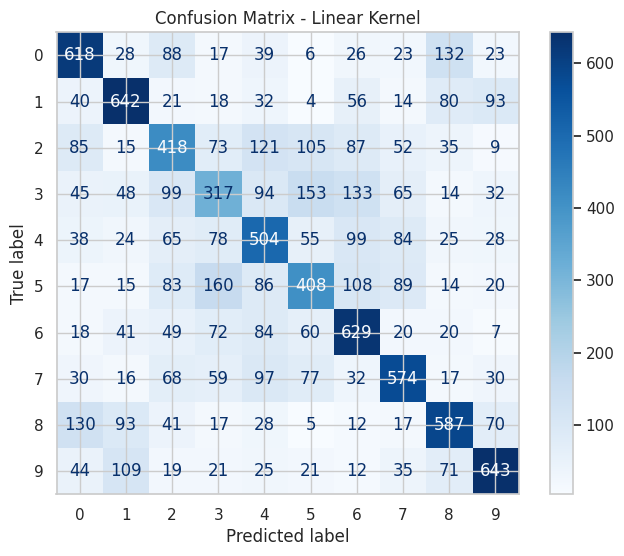

Training and Evaluating Kernels:  25%|██▌       | 1/4 [09:26<28:18, 566.14s/it]


Starting with the 'poly' kernel...
Done! Accuracy: 0.6255 | Time taken: 740.51 sec

Classification Report for POLY Kernel:
              precision    recall  f1-score   support

           0       0.74      0.67      0.70      1000
           1       0.79      0.74      0.77      1000
           2       0.63      0.44      0.52      1000
           3       0.48      0.35      0.41      1000
           4       0.42      0.75      0.54      1000
           5       0.53      0.49      0.51      1000
           6       0.62      0.73      0.67      1000
           7       0.77      0.63      0.69      1000
           8       0.75      0.68      0.71      1000
           9       0.68      0.77      0.72      1000

    accuracy                           0.63     10000
   macro avg       0.64      0.63      0.62     10000
weighted avg       0.64      0.63      0.62     10000



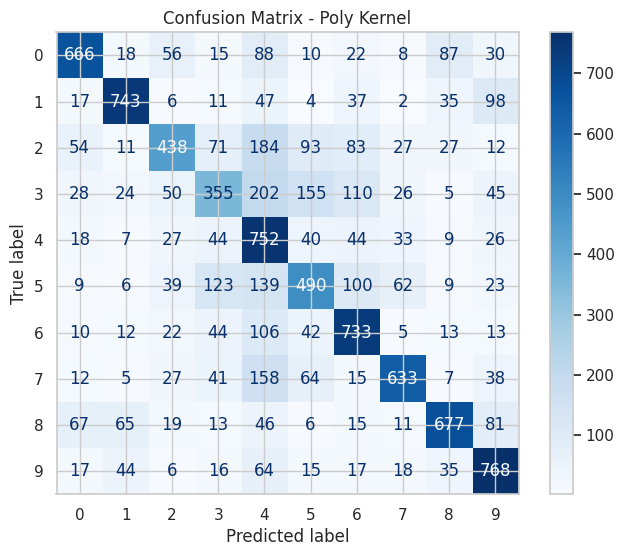

Training and Evaluating Kernels:  50%|█████     | 2/4 [23:01<23:45, 712.76s/it]


Starting with the 'rbf' kernel...
Done! Accuracy: 0.6463 | Time taken: 545.64 sec

Classification Report for RBF Kernel:
              precision    recall  f1-score   support

           0       0.67      0.74      0.70      1000
           1       0.78      0.79      0.78      1000
           2       0.55      0.49      0.52      1000
           3       0.47      0.43      0.45      1000
           4       0.56      0.62      0.59      1000
           5       0.52      0.52      0.52      1000
           6       0.69      0.73      0.71      1000
           7       0.72      0.67      0.69      1000
           8       0.74      0.72      0.73      1000
           9       0.74      0.75      0.75      1000

    accuracy                           0.65     10000
   macro avg       0.64      0.65      0.64     10000
weighted avg       0.64      0.65      0.64     10000



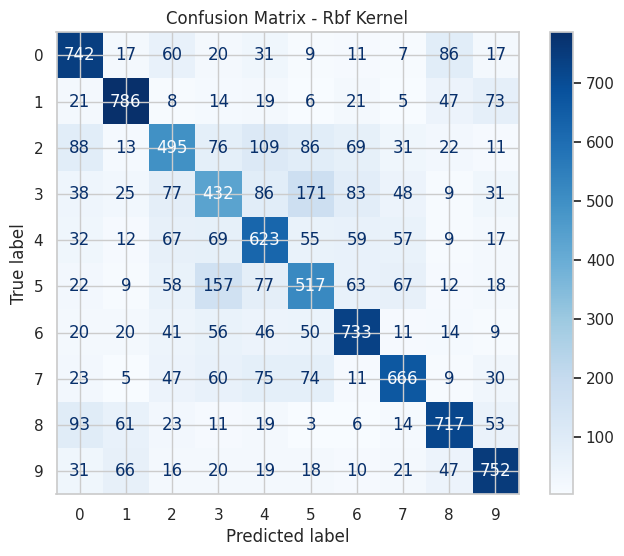

Training and Evaluating Kernels:  75%|███████▌  | 3/4 [34:20<11:37, 697.23s/it]


Starting with the 'sigmoid' kernel...
Done! Accuracy: 0.4006 | Time taken: 521.73 sec

Classification Report for SIGMOID Kernel:
              precision    recall  f1-score   support

           0       0.42      0.43      0.43      1000
           1       0.47      0.49      0.48      1000
           2       0.26      0.28      0.27      1000
           3       0.32      0.18      0.23      1000
           4       0.43      0.37      0.40      1000
           5       0.30      0.34      0.32      1000
           6       0.41      0.48      0.44      1000
           7       0.47      0.39      0.43      1000
           8       0.36      0.55      0.44      1000
           9       0.63      0.50      0.56      1000

    accuracy                           0.40     10000
   macro avg       0.41      0.40      0.40     10000
weighted avg       0.41      0.40      0.40     10000



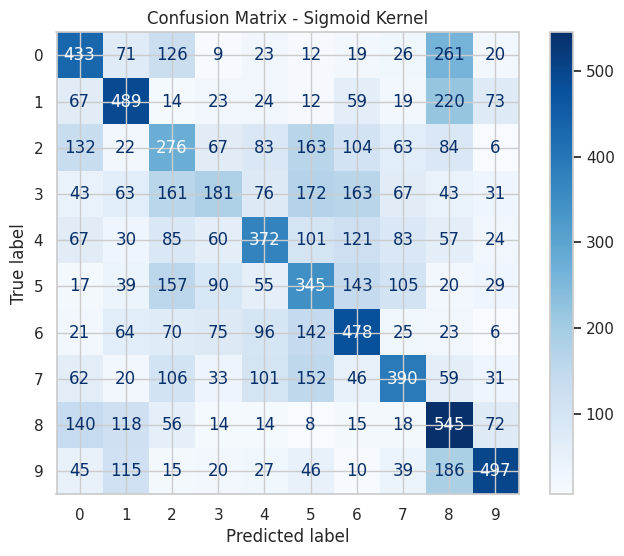

Training and Evaluating Kernels: 100%|██████████| 4/4 [44:22<00:00, 665.69s/it]


In [5]:
# looping through each kernel to train and evaluate
from sklearn.metrics import classification_report
for kernel in tqdm(kernels, desc="Training and Evaluating Kernels"):
    print(f"\nStarting with the '{kernel}' kernel...")

    start_time = time.time()

    # train the SVM model
    clf = SVC(kernel=kernel)
    clf.fit(X_train, y_train)

    elapsed = time.time() - start_time
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # print out results for the kernel
    print(f"Done! Accuracy: {acc:.4f} | Time taken: {elapsed:.2f} sec")

    # save the model and prediction
    models[kernel] = clf
    predictions[kernel] = y_pred
    accuracies.append(acc)
    times.append(elapsed)

    # save model to disk
    with open(f'svm_{kernel}.pkl', 'wb') as f:
        pickle.dump(clf, f)

    # print classification report and confusion matrix
    print(f"\nClassification Report for {kernel.upper()} Kernel:")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
    plt.title(f"Confusion Matrix - {kernel.capitalize()} Kernel")
    plt.show()


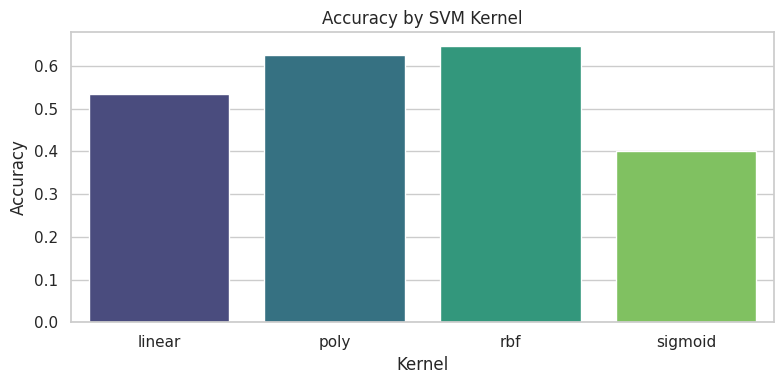

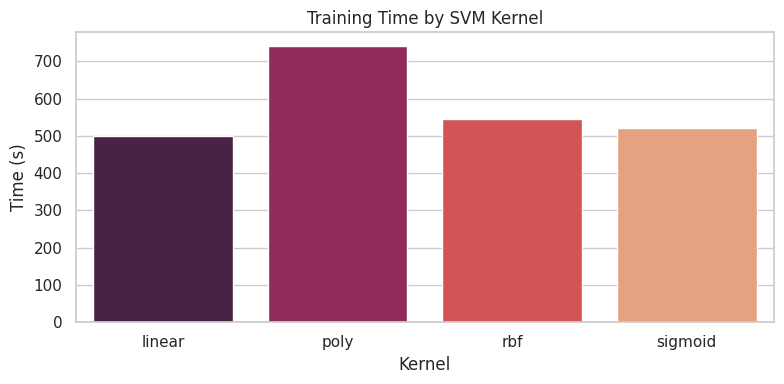

In [6]:
# plot comparison of accuracies
plt.figure(figsize=(8, 4))
sns.barplot(x=kernels, y=accuracies, palette='viridis')
plt.title("Accuracy by SVM Kernel")
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

# plot comparison of training times
plt.figure(figsize=(8, 4))
sns.barplot(x=kernels, y=times, palette='rocket')
plt.title("Training Time by SVM Kernel")
plt.xlabel("Kernel")
plt.ylabel("Time (s)")
plt.tight_layout()
plt.show()


In [7]:
# determine and print best kernel based on accuracy
best_idx = np.argmax(accuracies)
best_kernel = kernels[best_idx]
best_acc = accuracies[best_idx]

print(f"\n🏆 The best kernel is: '{best_kernel}' with Accuracy = {best_acc:.4f}")



🏆 The best kernel is: 'rbf' with Accuracy = 0.6463
